Bordes

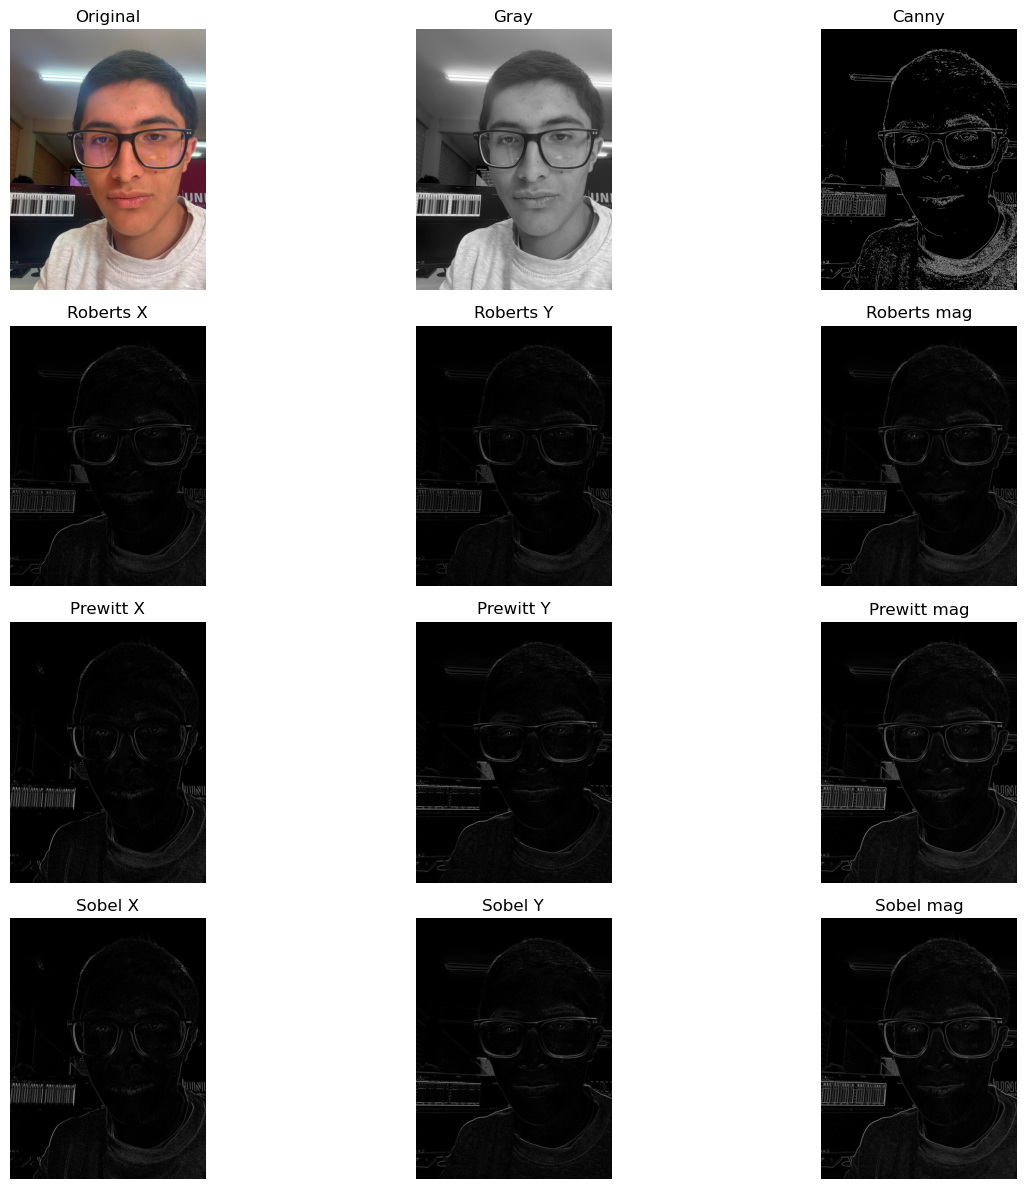

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('imagen1.jpg')
if img is None:
    raise FileNotFoundError('imagen1.jpg no se encontró en el directorio actual')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# ROBERTS
robertx = np.array([[-1, 0], [0, 1]])
roberty = np.array([[0, -1], [1, 0]])

robx_img = cv2.filter2D(gray, cv2.CV_64F, robertx)
roby_img = cv2.filter2D(gray, cv2.CV_64F, roberty)
rob_grad = np.sqrt(robx_img**2 + roby_img**2)

# PREWITT
prewitt_x = np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]])
prewitt_y = np.array([[-1, -1, -1], [0, 0, 0], [1, 1, 1]])

prex_img = cv2.filter2D(gray, cv2.CV_64F, prewitt_x)
prey_img = cv2.filter2D(gray, cv2.CV_64F, prewitt_y)
prewitt_mag = np.sqrt(prex_img**2 + prey_img**2)

# SOBEL
sobel_x = np.array([[-1,0,1],[-2,0,2],[-1,0,1]])
sobel_y = np.array([[-1,-2,-1],[0,0,0],[1,2,1]])

sobelx_img = cv2.filter2D(gray, cv2.CV_64F, sobel_x)
sobely_img = cv2.filter2D(gray, cv2.CV_64F, sobel_y)
sobel_mag = np.sqrt(sobelx_img**2 + sobely_img**2)

# CANNY
canny_img = cv2.Canny(gray, 100, 100)

# NORMALIZAR PARA MOSTRAR
robx_show = cv2.normalize(np.abs(robx_img), None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
roby_show = cv2.normalize(np.abs(roby_img), None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
rob_mag_show = cv2.normalize(rob_grad, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
prex_show = cv2.normalize(np.abs(prex_img), None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
prey_show = cv2.normalize(np.abs(prey_img), None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
pre_mag_show = cv2.normalize(prewitt_mag, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
sobelx_show = cv2.normalize(np.abs(sobelx_img), None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
sobely_show = cv2.normalize(np.abs(sobely_img), None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
sobel_mag_show = cv2.normalize(sobel_mag, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

plt.figure(figsize=(14,12))

plt.subplot(4,3,1)
plt.title('Original')
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.subplot(4,3,2)
plt.title('Gray')
plt.imshow(gray, cmap='gray')
plt.axis('off')

plt.subplot(4,3,3)
plt.title('Canny')
plt.imshow(canny_img, cmap='gray')
plt.axis('off')

plt.subplot(4,3,4)
plt.title('Roberts X')
plt.imshow(robx_show, cmap='gray')
plt.axis('off')

plt.subplot(4,3,5)
plt.title('Roberts Y')
plt.imshow(roby_show, cmap='gray')
plt.axis('off')

plt.subplot(4,3,6)
plt.title('Roberts mag')
plt.imshow(rob_mag_show, cmap='gray')
plt.axis('off')

plt.subplot(4,3,7)
plt.title('Prewitt X')
plt.imshow(prex_show, cmap='gray')
plt.axis('off')

plt.subplot(4,3,8)
plt.title('Prewitt Y')
plt.imshow(prey_show, cmap='gray')
plt.axis('off')

plt.subplot(4,3,9)
plt.title('Prewitt mag')
plt.imshow(pre_mag_show, cmap='gray')
plt.axis('off')

plt.subplot(4,3,10)
plt.title('Sobel X')
plt.imshow(sobelx_show, cmap='gray')
plt.axis('off')

plt.subplot(4,3,11)
plt.title('Sobel Y')
plt.imshow(sobely_show, cmap='gray')
plt.axis('off')

plt.subplot(4,3,12)
plt.title('Sobel mag')
plt.imshow(sobel_mag_show, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

Sobel

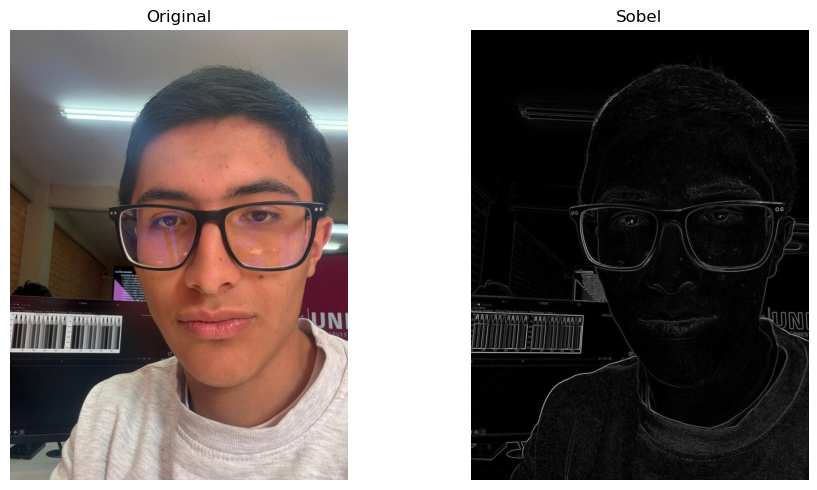

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
def filtro_sobel(img):
    img_gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    g_x = cv2.Sobel(img_gris, cv2.CV_64F, 1, 0, ksize=3)
    g_y = cv2.Sobel(img_gris, cv2.CV_64F, 0, 1, ksize=3)
    mag = np.sqrt(np.square(g_x) + np.square(g_y))
    mag = cv2.normalize(mag, None, 0, 255, cv2.NORM_MINMAX)
    return mag

img = cv2.imread('imagen1.jpg')
if img is None:
    raise FileNotFoundError('imagen1.jpg no se encontró en el directorio actual')
sobel_img = filtro_sobel(img)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title('Original')
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.subplot(1,2,2)
plt.title('Sobel')
plt.imshow(sobel_img, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()
    

Sobel mejorado 

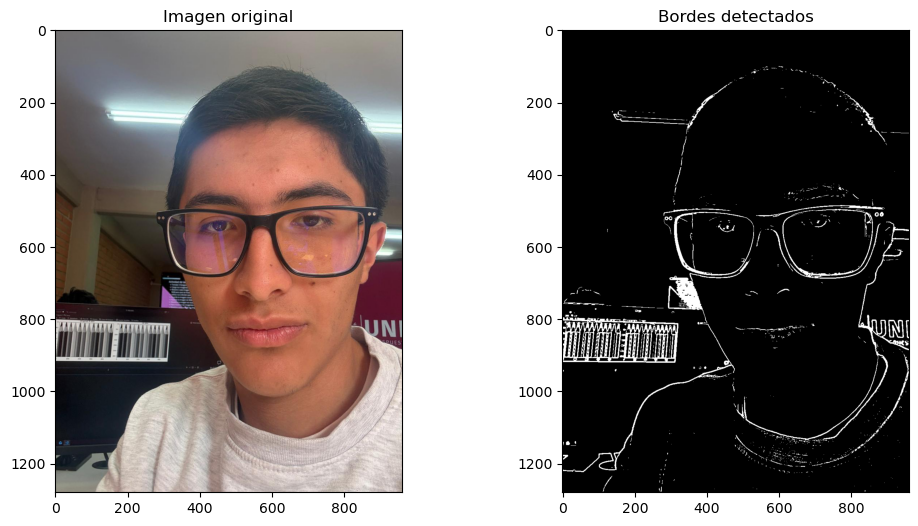

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


def filtro_sobel_mejorado(img, kernel_size=3, umbral=30):
    img_gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img_gris = cv2.GaussianBlur(img_gris, (3, 3), 0)

    g_x = cv2.Sobel(img_gris, cv2.CV_64F, 1, 0, ksize=kernel_size)
    g_y = cv2.Sobel(img_gris, cv2.CV_64F, 0, 1, ksize=kernel_size)

    mag = np.sqrt(g_x**2 + g_y**2)
    mag = cv2.normalize(mag, None, 0, 255, cv2.NORM_MINMAX, cv2.CV_8U)

    _, bordes = cv2.threshold(
        mag, umbral, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    kernel = np.ones((2, 2), np.uint8)
    bordes = cv2.morphologyEx(bordes, cv2.MORPH_CLOSE, kernel)

    return bordes


ruta = "imagen1.jpg"
img = cv2.imread(ruta)

if img is None:
    print("Error: no se pudo cargar la imagen")
else:
    bordes = filtro_sobel_mejorado(img)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    plt.imshow(img_rgb)
    plt.title("Imagen original")
    plt.axis("on")

    plt.subplot(1, 2, 2)
    plt.imshow(bordes, cmap="gray")
    plt.title("Bordes detectados")
    plt.axis("on")

    plt.show()

robert

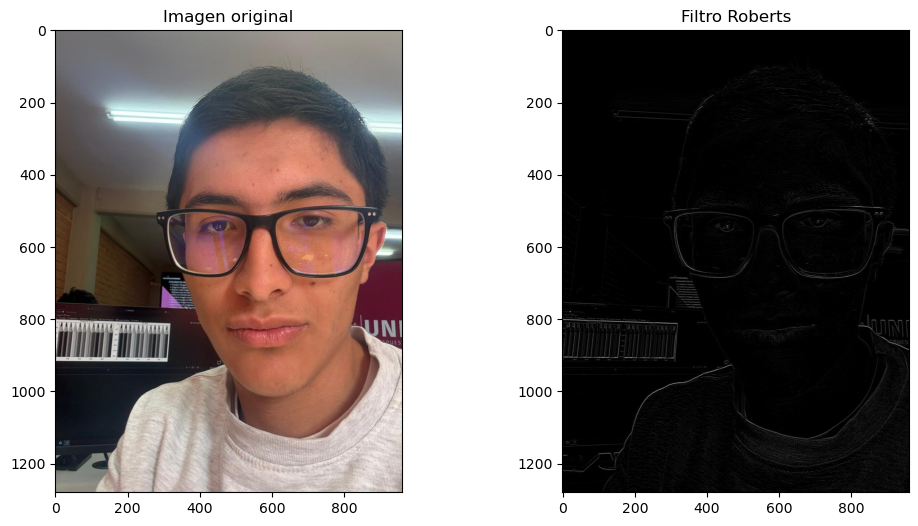

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


def filtro_roberts(img):
    img_gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    robertx = np.array([[-1, 0], [0, 1]], dtype=np.float32)
    roberty = np.array([[0, -1], [1, 0]], dtype=np.float32)

    r_x = cv2.filter2D(img_gris, -1, robertx)
    r_y = cv2.filter2D(img_gris, -1, roberty)

    roberts = cv2.addWeighted(r_x, 0.5, r_y, 0.5, 0)

    return roberts


ruta = "imagen1.jpg"
img = cv2.imread(ruta)

if img is None:
    print("Error: no se pudo cargar la imagen")
else:
    roberts = filtro_roberts(img)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    plt.imshow(img_rgb)
    plt.title("Imagen original")
    plt.axis("on")

    plt.subplot(1, 2, 2)
    plt.imshow(roberts, cmap="gray")
    plt.title("Filtro Roberts")
    plt.axis("on")

    plt.show()